In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report, confusion_matrix,
                           precision_recall_fscore_support, roc_curve)

# Visualization settings
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# ===== LOAD AND EXPLORE DATASET =====

In [2]:

# Load the dataset
df = pd.read_excel('MS_Capstone_Final_Quality_Check_Summary.xlsx', sheet_name='clean_data')

print("📊 DATASET OVERVIEW")
print("=" * 40)
print(f"Dataset shape: {df.shape}")
print(f"Number of companies: {df['Company'].nunique()}")
print(f"Date range: {df['Period'].min()} to {df['Period'].max()}")
print()

# Target variable distribution
print("🎯 TARGET VARIABLE DISTRIBUTION")
print("-" * 35)
target_dist = df['Movement Label (1,0)'].value_counts()
print(f"Down movements (0): {target_dist[0]} ({target_dist[0]/len(df)*100:.1f}%)")
print(f"Up movements (1): {target_dist[1]} ({target_dist[1]/len(df)*100:.1f}%)")
print()

# Display basic statistics
print("📈 3-DAY RETURN STATISTICS")
print("-" * 30)
print(f"Mean: {df['3-Day Return (%)'].mean():.2f}%")
print(f"Std: {df['3-Day Return (%)'].std():.2f}%")
print(f"Min: {df['3-Day Return (%)'].min():.2f}%")
print(f"Max: {df['3-Day Return (%)'].max():.2f}%")
print()

print("✅ Dataset loaded and explored successfully!")

📊 DATASET OVERVIEW
Dataset shape: (585, 32)
Number of companies: 45
Date range: 2022-06-01 00:00:00 to Sep 2024

🎯 TARGET VARIABLE DISTRIBUTION
-----------------------------------
Down movements (0): 344 (58.8%)
Up movements (1): 240 (41.0%)

📈 3-DAY RETURN STATISTICS
------------------------------
Mean: 0.29%
Std: 4.28%
Min: -12.01%
Max: 19.08%

✅ Dataset loaded and explored successfully!


# ===== DATA PREPROCESSING =====

In [4]:
# Drop NaN values from target variable
target_col = "Movement Label (1,0)"   # <-- replace with your actual target column name

# Count NaNs before dropping
nan_count = df[target_col].isna().sum()
print(f"🔍 Found {nan_count} missing values in target column '{target_col}'.")

# Drop rows where target is NaN
df = df[df[target_col].notna()].copy()

# Confirm new shape
print(f"✅ After dropping NaNs in '{target_col}', dataset shape: {df.shape}")


🔍 Found 1 missing values in target column 'Movement Label (1,0)'.
✅ After dropping NaNs in 'Movement Label (1,0)', dataset shape: (584, 32)


In [5]:
# Select features for modeling (excluding target and non-predictive columns)
feature_columns = [
    'Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income',
    'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit',
    'EPS in Rs', 'Revenue', 'Financing Profit', 'Financing Margin %',
    'Closing Price (T)'
]

# Create feature matrix and target vector
X = df[feature_columns].copy()
y = df['Movement Label (1,0)'].copy()

print("🔧 DATA PREPROCESSING")
print("=" * 30)
print(f"Features selected: {len(feature_columns)}")
print(f"Feature columns: {feature_columns}")
print()

# Handle missing values
print("📊 MISSING VALUES CHECK")
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print("Missing values found:")
    for col, count in missing_counts[missing_counts > 0].items():
        print(f"  {col}: {count}")
    # Fill missing values with median
    X = X.fillna(X.median())
    print("✅ Missing values filled with median")
else:
    print("✅ No missing values found")
print()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("📊 DATA SPLIT SUMMARY")
print("-" * 25)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print()

# Check class distribution in splits
train_dist = pd.Series(y_train).value_counts()
test_dist = pd.Series(y_test).value_counts()
print("🎯 CLASS DISTRIBUTION IN SPLITS")
print("-" * 35)
print(f"Training - Down: {train_dist[0]} ({train_dist[0]/len(y_train)*100:.1f}%), Up: {train_dist[1]} ({train_dist[1]/len(y_train)*100:.1f}%)")
print(f"Test - Down: {test_dist[0]} ({test_dist[0]/len(y_test)*100:.1f}%), Up: {test_dist[1]} ({test_dist[1]/len(y_test)*100:.1f}%)")
print()

print("✅ Data preprocessing completed successfully!")

🔧 DATA PREPROCESSING
Features selected: 15
Feature columns: ['Sales', 'Expenses', 'Operating Profit', 'OPM %', 'Other Income', 'Interest', 'Depreciation', 'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs', 'Revenue', 'Financing Profit', 'Financing Margin %', 'Closing Price (T)']

📊 MISSING VALUES CHECK
Missing values found:
  Sales: 117
  Operating Profit: 117
  OPM %: 117
  Revenue: 467
  Financing Profit: 467
  Financing Margin %: 467
✅ Missing values filled with median

📊 DATA SPLIT SUMMARY
-------------------------
Training set: 467 samples
Test set: 117 samples
Features: 15

🎯 CLASS DISTRIBUTION IN SPLITS
-----------------------------------
Training - Down: 275 (58.9%), Up: 192 (41.1%)
Test - Down: 69 (59.0%), Up: 48 (41.0%)

✅ Data preprocessing completed successfully!


# ===== LOGISTIC REGRESSION BASELINE MODEL =====

In [6]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_results = {
    'train_accuracy': accuracy_score(y_train, lr_train_pred),
    'test_accuracy': accuracy_score(y_test, lr_test_pred),
    'train_precision': precision_score(y_train, lr_train_pred, average='weighted'),
    'test_precision': precision_score(y_test, lr_test_pred, average='weighted'),
    'train_recall': recall_score(y_train, lr_train_pred, average='weighted'),
    'test_recall': recall_score(y_test, lr_test_pred, average='weighted'),
    'train_f1': f1_score(y_train, lr_train_pred, average='weighted'),
    'test_f1': f1_score(y_test, lr_test_pred, average='weighted'),
    'train_auc': roc_auc_score(y_train, lr_train_proba),
    'test_auc': roc_auc_score(y_test, lr_test_proba)
}

# Print results
print("📊 PERFORMANCE METRICS")
print("-" * 25)
for metric, value in lr_results.items():
    print(f"{metric}: {value:.3f}")

print()
print("📋 CLASSIFICATION REPORT (Test Set)")
print("-" * 40)
print(classification_report(y_test, lr_test_pred, target_names=['Down', 'Up']))

print()
print("🔢 CONFUSION MATRIX (Test Set)")
print("-" * 35)
cm_lr = confusion_matrix(y_test, lr_test_pred)
print(f"                Predicted")
print(f"Actual    Down    Up")
print(f"Down      {cm_lr[0,0]:4d}   {cm_lr[0,1]:4d}")
print(f"Up        {cm_lr[1,0]:4d}   {cm_lr[1,1]:4d}")

print()
print("✅ Logistic Regression model completed!")


📊 PERFORMANCE METRICS
-------------------------
train_accuracy: 0.615
test_accuracy: 0.598
train_precision: 0.606
test_precision: 0.577
train_recall: 0.615
test_recall: 0.598
train_f1: 0.560
test_f1: 0.546
train_auc: 0.619
test_auc: 0.485

📋 CLASSIFICATION REPORT (Test Set)
----------------------------------------
              precision    recall  f1-score   support

        Down       0.61      0.87      0.72        69
          Up       0.53      0.21      0.30        48

    accuracy                           0.60       117
   macro avg       0.57      0.54      0.51       117
weighted avg       0.58      0.60      0.55       117


🔢 CONFUSION MATRIX (Test Set)
-----------------------------------
                Predicted
Actual    Down    Up
Down        60      9
Up          38     10

✅ Logistic Regression model completed!


# ===== RANDOM FOREST BASELINE MODEL =====

In [7]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)
rf_train_proba = rf_model.predict_proba(X_train_scaled)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
rf_results = {
    'train_accuracy': accuracy_score(y_train, rf_train_pred),
    'test_accuracy': accuracy_score(y_test, rf_test_pred),
    'train_precision': precision_score(y_train, rf_train_pred, average='weighted'),
    'test_precision': precision_score(y_test, rf_test_pred, average='weighted'),
    'train_recall': recall_score(y_train, rf_train_pred, average='weighted'),
    'test_recall': recall_score(y_test, rf_test_pred, average='weighted'),
    'train_f1': f1_score(y_train, rf_train_pred, average='weighted'),
    'test_f1': f1_score(y_test, rf_test_pred, average='weighted'),
    'train_auc': roc_auc_score(y_train, rf_train_proba),
    'test_auc': roc_auc_score(y_test, rf_test_proba)
}

# Print results
print("📊 PERFORMANCE METRICS")
print("-" * 25)
for metric, value in rf_results.items():
    print(f"{metric}: {value:.3f}")

print()
print("📋 CLASSIFICATION REPORT (Test Set)")
print("-" * 40)
print(classification_report(y_test, rf_test_pred, target_names=['Down', 'Up']))

print()
print("🔢 CONFUSION MATRIX (Test Set)")
print("-" * 35)
cm_rf = confusion_matrix(y_test, rf_test_pred)
print(f"                Predicted")
print(f"Actual    Down    Up")
print(f"Down      {cm_rf[0,0]:4d}   {cm_rf[0,1]:4d}")
print(f"Up        {cm_rf[1,0]:4d}   {cm_rf[1,1]:4d}")

print()
print("✅ Random Forest model completed!")

📊 PERFORMANCE METRICS
-------------------------
train_accuracy: 1.000
test_accuracy: 0.547
train_precision: 1.000
test_precision: 0.531
train_recall: 1.000
test_recall: 0.547
train_f1: 1.000
test_f1: 0.534
train_auc: 1.000
test_auc: 0.489

📋 CLASSIFICATION REPORT (Test Set)
----------------------------------------
              precision    recall  f1-score   support

        Down       0.60      0.70      0.64        69
          Up       0.43      0.33      0.38        48

    accuracy                           0.55       117
   macro avg       0.52      0.51      0.51       117
weighted avg       0.53      0.55      0.53       117


🔢 CONFUSION MATRIX (Test Set)
-----------------------------------
                Predicted
Actual    Down    Up
Down        48     21
Up          32     16

✅ Random Forest model completed!


# ===== XGBOOST BASELINE MODEL =====

In [8]:
# Train XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
xgb_train_pred = xgb_model.predict(X_train_scaled)
xgb_test_pred = xgb_model.predict(X_test_scaled)
xgb_train_proba = xgb_model.predict_proba(X_train_scaled)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
xgb_results = {
    'train_accuracy': accuracy_score(y_train, xgb_train_pred),
    'test_accuracy': accuracy_score(y_test, xgb_test_pred),
    'train_precision': precision_score(y_train, xgb_train_pred, average='weighted'),
    'test_precision': precision_score(y_test, xgb_test_pred, average='weighted'),
    'train_recall': recall_score(y_train, xgb_train_pred, average='weighted'),
    'test_recall': recall_score(y_test, xgb_test_pred, average='weighted'),
    'train_f1': f1_score(y_train, xgb_train_pred, average='weighted'),
    'test_f1': f1_score(y_test, xgb_test_pred, average='weighted'),
    'train_auc': roc_auc_score(y_train, xgb_train_proba),
    'test_auc': roc_auc_score(y_test, xgb_test_proba)
}

# Print results
print("📊 PERFORMANCE METRICS")
print("-" * 25)
for metric, value in xgb_results.items():
    print(f"{metric}: {value:.3f}")

print()
print("📋 CLASSIFICATION REPORT (Test Set)")
print("-" * 40)
print(classification_report(y_test, xgb_test_pred, target_names=['Down', 'Up']))

print()
print("🔢 CONFUSION MATRIX (Test Set)")
print("-" * 35)
cm_xgb = confusion_matrix(y_test, xgb_test_pred)
print(f"                Predicted")
print(f"Actual    Down    Up")
print(f"Down      {cm_xgb[0,0]:4d}   {cm_xgb[0,1]:4d}")
print(f"Up        {cm_xgb[1,0]:4d}   {cm_xgb[1,1]:4d}")

print()
print("✅ XGBoost model completed!")

📊 PERFORMANCE METRICS
-------------------------
train_accuracy: 1.000
test_accuracy: 0.564
train_precision: 1.000
test_precision: 0.547
train_recall: 1.000
test_recall: 0.564
train_f1: 1.000
test_f1: 0.549
train_auc: 1.000
test_auc: 0.547

📋 CLASSIFICATION REPORT (Test Set)
----------------------------------------
              precision    recall  f1-score   support

        Down       0.61      0.72      0.66        69
          Up       0.46      0.33      0.39        48

    accuracy                           0.56       117
   macro avg       0.53      0.53      0.52       117
weighted avg       0.55      0.56      0.55       117


🔢 CONFUSION MATRIX (Test Set)
-----------------------------------
                Predicted
Actual    Down    Up
Down        50     19
Up          32     16

✅ XGBoost model completed!


# ===== PERFORMANCE COMPARISON VISUALIZATION - PART 1 =====

📊 CREATING PERFORMANCE COMPARISON VISUALIZATIONS


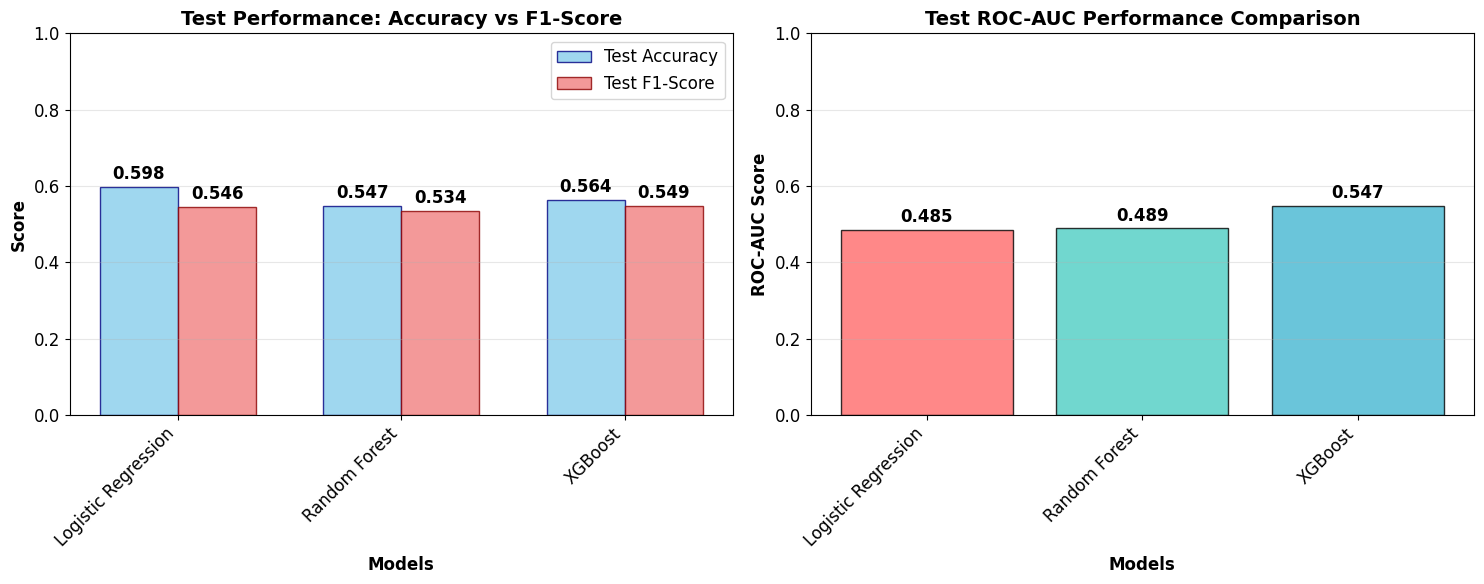

✅ Performance comparison visualization 1 completed!


In [9]:
# Create comprehensive comparison of all models
print("📊 CREATING PERFORMANCE COMPARISON VISUALIZATIONS")
print("=" * 50)

# Compile all results
all_results = {
    'Logistic Regression': lr_results,
    'Random Forest': rf_results,
    'XGBoost': xgb_results
}

# Create comparison DataFrame
comparison_data = []
for model_name, results in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Train_Accuracy': results['train_accuracy'],
        'Test_Accuracy': results['test_accuracy'],
        'Train_F1': results['train_f1'],
        'Test_F1': results['test_f1'],
        'Train_AUC': results['train_auc'],
        'Test_AUC': results['test_auc'],
        'Overfitting_Gap_Acc': results['train_accuracy'] - results['test_accuracy'],
        'Overfitting_Gap_F1': results['train_f1'] - results['test_f1']
    })

comparison_df = pd.DataFrame(comparison_data)

# Visualization 1: Test Performance Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Test Accuracy vs F1-Score
models = comparison_df['Model']
test_acc = comparison_df['Test_Accuracy']
test_f1 = comparison_df['Test_F1']

x_pos = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, test_acc, width, label='Test Accuracy', 
                color='skyblue', alpha=0.8, edgecolor='navy')
bars2 = ax1.bar(x_pos + width/2, test_f1, width, label='Test F1-Score', 
                color='lightcoral', alpha=0.8, edgecolor='darkred')

ax1.set_xlabel('Models', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Test Performance: Accuracy vs F1-Score', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: ROC-AUC Comparison
test_auc = comparison_df['Test_AUC']
bars3 = ax2.bar(models, test_auc, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                alpha=0.8, edgecolor='black')

ax2.set_xlabel('Models', fontweight='bold')
ax2.set_ylabel('ROC-AUC Score', fontweight='bold')
ax2.set_title('Test ROC-AUC Performance Comparison', fontweight='bold', fontsize=14)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Performance comparison visualization 1 completed!")

# ===== OVERFITTING ANALYSIS VISUALIZATION - PART 2 =====

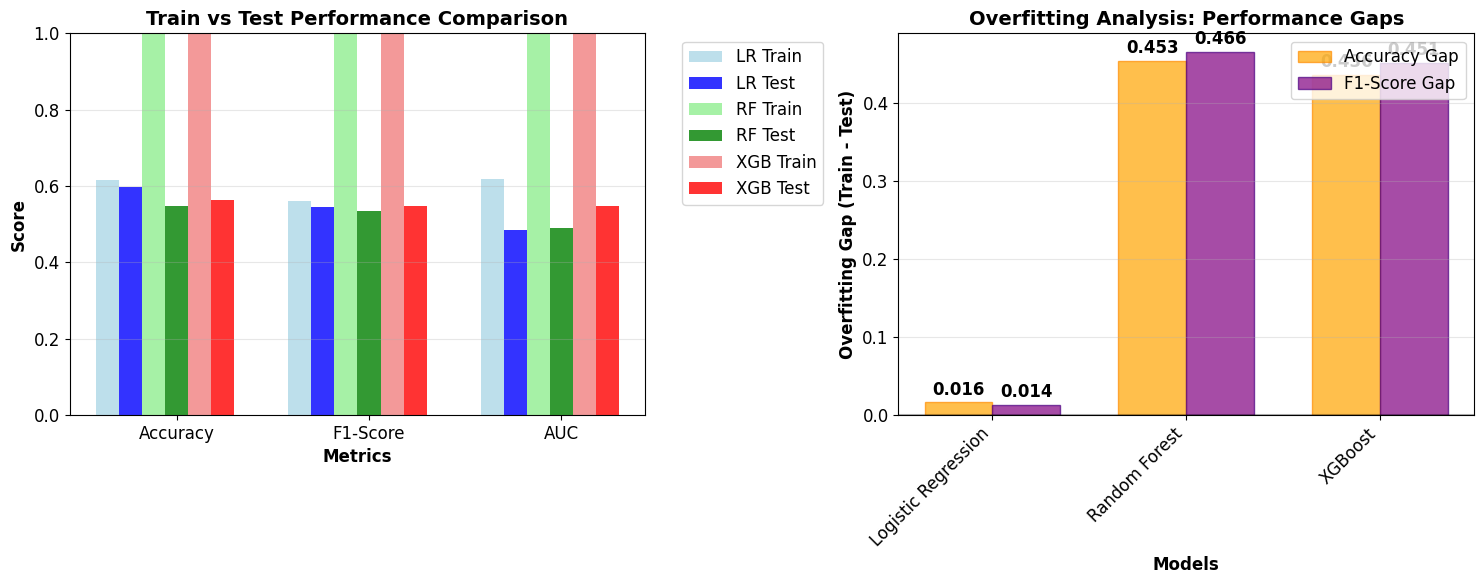

✅ Overfitting analysis visualization completed!


In [10]:
# Visualization 2: Overfitting Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Train vs Test Performance
metrics = ['Accuracy', 'F1-Score', 'AUC']
lr_train = [lr_results['train_accuracy'], lr_results['train_f1'], lr_results['train_auc']]
lr_test = [lr_results['test_accuracy'], lr_results['test_f1'], lr_results['test_auc']]
rf_train = [rf_results['train_accuracy'], rf_results['train_f1'], rf_results['train_auc']]
rf_test = [rf_results['test_accuracy'], rf_results['test_f1'], rf_results['test_auc']]
xgb_train = [xgb_results['train_accuracy'], xgb_results['train_f1'], xgb_results['train_auc']]
xgb_test = [xgb_results['test_accuracy'], xgb_results['test_f1'], xgb_results['test_auc']]

x_pos = np.arange(len(metrics))
width = 0.12

# Create grouped bars
bars1 = ax1.bar(x_pos - 2*width, lr_train, width, label='LR Train', color='lightblue', alpha=0.8)
bars2 = ax1.bar(x_pos - width, lr_test, width, label='LR Test', color='blue', alpha=0.8)
bars3 = ax1.bar(x_pos, rf_train, width, label='RF Train', color='lightgreen', alpha=0.8)
bars4 = ax1.bar(x_pos + width, rf_test, width, label='RF Test', color='green', alpha=0.8)
bars5 = ax1.bar(x_pos + 2*width, xgb_train, width, label='XGB Train', color='lightcoral', alpha=0.8)
bars6 = ax1.bar(x_pos + 3*width, xgb_test, width, label='XGB Test', color='red', alpha=0.8)

ax1.set_xlabel('Metrics', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Train vs Test Performance Comparison', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(metrics)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Chart 2: Overfitting Gap Analysis
gap_acc = comparison_df['Overfitting_Gap_Acc']
gap_f1 = comparison_df['Overfitting_Gap_F1']

x_pos = np.arange(len(models))
width = 0.35

bars7 = ax2.bar(x_pos - width/2, gap_acc, width, label='Accuracy Gap', 
                color='orange', alpha=0.7, edgecolor='darkorange')
bars8 = ax2.bar(x_pos + width/2, gap_f1, width, label='F1-Score Gap', 
                color='purple', alpha=0.7, edgecolor='indigo')

ax2.set_xlabel('Models', fontweight='bold')
ax2.set_ylabel('Overfitting Gap (Train - Test)', fontweight='bold')
ax2.set_title('Overfitting Analysis: Performance Gaps', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for bar in bars7:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

for bar in bars8:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Overfitting analysis visualization completed!")


# ===== CONFUSION MATRIX VISUALIZATION =====

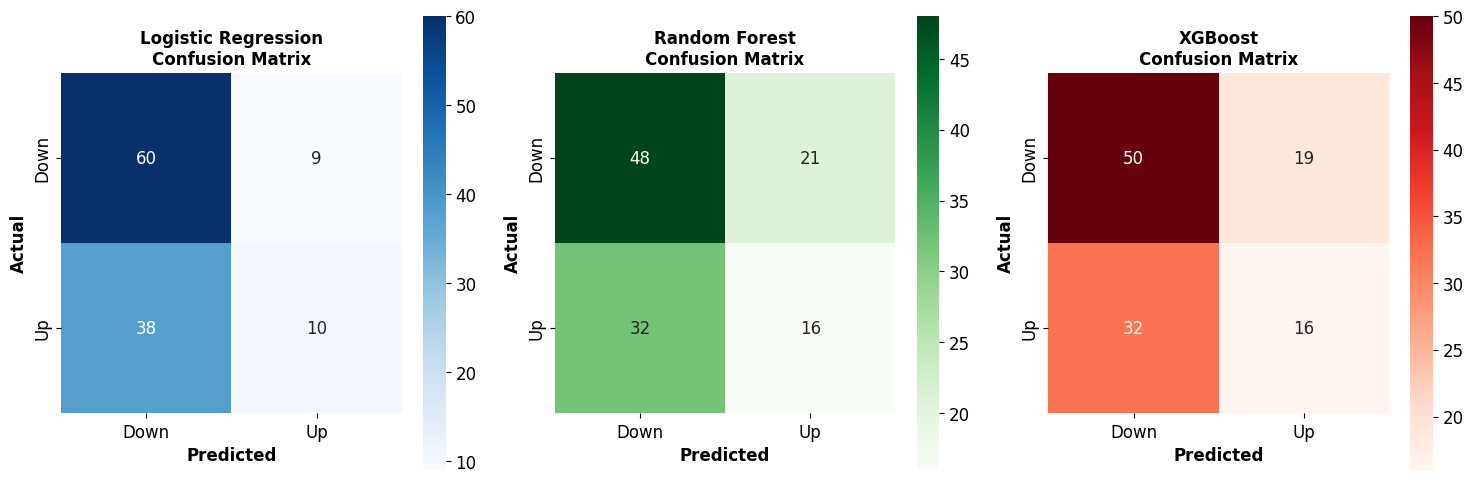

✅ Confusion matrix visualization completed!


In [12]:
# Create confusion matrix comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion matrices
cms = [cm_lr, cm_rf, cm_xgb]
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors = ['Blues', 'Greens', 'Reds']

for i, (cm, name, color) in enumerate(zip(cms, model_names, colors)):
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, 
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'],
                ax=axes[i], cbar=True, square=True)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted', fontweight='bold')
    axes[i].set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Confusion matrix visualization completed!")


# ===== ROC CURVES AND FINAL SUMMARY =====

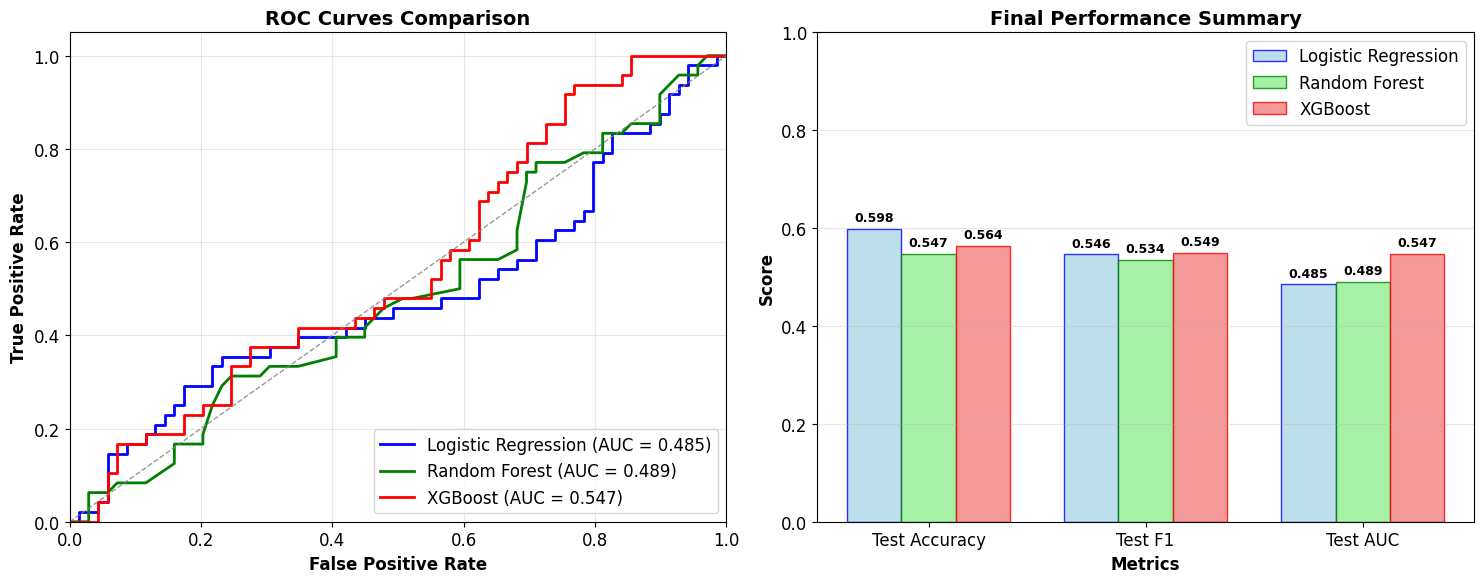


🏆 FINAL BASELINE MODELS SUMMARY REPORT

📊 MODEL PERFORMANCE RANKING (by Test Accuracy):
--------------------------------------------------
1. Logistic Regression
   • Test Accuracy: 0.598
   • Test F1-Score: 0.546
   • Test ROC-AUC: 0.485
   • Overfitting Risk: 0.016

2. XGBoost
   • Test Accuracy: 0.564
   • Test F1-Score: 0.549
   • Test ROC-AUC: 0.547
   • Overfitting Risk: 0.436

3. Random Forest
   • Test Accuracy: 0.547
   • Test F1-Score: 0.534
   • Test ROC-AUC: 0.489
   • Overfitting Risk: 0.453

🎯 RECOMMENDATION:
--------------------
Best performing baseline model: Logistic Regression
Achieves 59.8% test accuracy with 0.485 AUC

Complete baseline models analysis finished!


In [14]:
# ROC Curves Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: ROC Curves
# Calculate ROC curves for all models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_test_proba)

ax1.plot(lr_fpr, lr_tpr, color='blue', lw=2, 
         label=f'Logistic Regression (AUC = {lr_results["test_auc"]:.3f})')
ax1.plot(rf_fpr, rf_tpr, color='green', lw=2, 
         label=f'Random Forest (AUC = {rf_results["test_auc"]:.3f})')
ax1.plot(xgb_fpr, xgb_tpr, color='red', lw=2, 
         label=f'XGBoost (AUC = {xgb_results["test_auc"]:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.8)

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('ROC Curves Comparison', fontweight='bold', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Chart 2: Final Performance Summary
summary_metrics = ['Test Accuracy', 'Test F1', 'Test AUC']
lr_summary = [lr_results['test_accuracy'], lr_results['test_f1'], lr_results['test_auc']]
rf_summary = [rf_results['test_accuracy'], rf_results['test_f1'], rf_results['test_auc']]
xgb_summary = [xgb_results['test_accuracy'], xgb_results['test_f1'], xgb_results['test_auc']]

x_pos = np.arange(len(summary_metrics))
width = 0.25

bars1 = ax2.bar(x_pos - width, lr_summary, width, label='Logistic Regression', 
                color='lightblue', alpha=0.8, edgecolor='blue')
bars2 = ax2.bar(x_pos, rf_summary, width, label='Random Forest', 
                color='lightgreen', alpha=0.8, edgecolor='green')
bars3 = ax2.bar(x_pos + width, xgb_summary, width, label='XGBoost', 
                color='lightcoral', alpha=0.8, edgecolor='red')

ax2.set_xlabel('Metrics', fontweight='bold')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Final Performance Summary', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(summary_metrics)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Final Summary Report
print()
print("🏆 FINAL BASELINE MODELS SUMMARY REPORT")
print("=" * 45)
print()

# Rank models by test accuracy
ranking_data = []
for model_name, results in all_results.items():
    ranking_data.append({
        'Model': model_name,
        'Test_Accuracy': results['test_accuracy'],
        'Test_F1': results['test_f1'],
        'Test_AUC': results['test_auc'],
        'Overfitting_Risk': results['train_accuracy'] - results['test_accuracy']
    })

ranking_df = pd.DataFrame(ranking_data)
ranking_df = ranking_df.sort_values('Test_Accuracy', ascending=False)

print("📊 MODEL PERFORMANCE RANKING (by Test Accuracy):")
print("-" * 50)
for i, row in ranking_df.iterrows():
    rank = ranking_df.index.get_loc(i) + 1
    print(f"{rank}. {row['Model']}")
    print(f"   • Test Accuracy: {row['Test_Accuracy']:.3f}")
    print(f"   • Test F1-Score: {row['Test_F1']:.3f}")
    print(f"   • Test ROC-AUC: {row['Test_AUC']:.3f}")
    print(f"   • Overfitting Risk: {row['Overfitting_Risk']:.3f}")
    print()

# Best model recommendation
best_model = ranking_df.iloc[0]
print("🎯 RECOMMENDATION:")
print("-" * 20)
print(f"Best performing baseline model: {best_model['Model']}")
print(f"Achieves {best_model['Test_Accuracy']:.1%} test accuracy with {best_model['Test_AUC']:.3f} AUC")
print()

print("Complete baseline models analysis finished!")
